# Modeling peroxisomal dysfunction in multiple sclerosis - PPI network analysis
## Overview
This analysis aims to investigate the involvement of peroxisomal dysfunction in multiple sclerosis (MS) by integrating transcriptomic data with network-based approaches. Specifically, this notebook concentrates on integration analysis of DEGs and PPI.

Author: Qing Zhang

Date of creation: 04/09/2025

Date of revision: 04/14/2025  

In [1]:
import pandas as pd
import requests
import networkx as nx
import matplotlib.pyplot as plt
from io import StringIO
from scipy.integrate import solve_ivp

## Load the DEGs 

In [3]:
deg_df = pd.read_csv("./DEGs_pv002.csv")
gene_list = deg_df.index.to_list()

## Start to build the network using PPI from STRING

In [8]:
# function to fetch PPI data from STRING 
def fetch_string_ppi(gene_list, species='9606'):
    base_url = "https://string-db.org/api/tsv/network"
    genes = "\n".join(gene_list)  # Join gene IDs into a newline-separated string
    params = {'identifiers': genes, 'species': species, 'limit': 1}
    response = requests.post(base_url, data=params)
    if response.status_code == 200:
        return response.text  # Return raw PPI data
    else:
        print("Failed to fetch data from STRING:", response.status_code)
        return None

In [9]:
# fetch PPI data from STRING using the degs
ppi_data = fetch_string_ppi(gene_list, species='9606')

In [10]:
# filter ppi to only keep the confident ones
ppi_df = pd.read_csv(StringIO(ppi_data), sep="\t")
ppi_df_filtered = ppi_df[ppi_df['score'] > 0.7]

In [7]:
ppi_df_filtered

,stringId_A,stringId_B,preferredName_A,preferredName_B,ncbiTaxonId,score,nscore,fscore,pscore,ascore,escore,dscore,tscore
7,9606.ENSP00000211998,9606.ENSP00000354573,VCL,MACF1,9606,0.710,0.000,0.0,0.000,0.132,0.123,0.000,0.649
9,9606.ENSP00000216024,9606.ENSP00000336606,DMC1,RAD54B,9606,0.724,0.042,0.0,0.000,0.000,0.591,0.000,0.352
21,9606.ENSP00000220592,9606.ENSP00000269305,AGO2,TP53,9606,0.872,0.000,0.0,0.000,0.000,0.167,0.500,0.719
22,9606.ENSP00000220592,9606.ENSP00000361626,AGO2,YBX1,9606,0.910,0.000,0.0,0.000,0.105,0.630,0.000,0.752
26,9606.ENSP00000221494,9606.ENSP00000466025,SF3A2,CIRBP,9606,0.730,0.000,0.0,0.000,0.120,0.650,0.000,0.193
27,9606.ENSP00000221494,9606.ENSP00000258962,SF3A2,SRSF1,9606,0.980,0.000,0.0,0.000,0.170,0.965,0.000,0.360
31,9606.ENSP00000222008,9606.ENSP00000368959,RABAC1,REEP5,9606,0.782,0.000,0.0,0.000,0.050,0.615,0.000,0.452
34,9606.ENSP00000225927,9606.ENSP00000368965,NAGLU,HGSNAT,9606,0.998,0.000,0.0,0.000,0.060,0.000,0.900,0.981
41,9606.ENSP00000232564,9606.ENSP00000316244,GNB4,HTR1A,9606,0.744,0.000,0.0,0.000,0.000,0.292,0.650,0.050
42,9606.ENSP00000232564,9606.ENSP00000501053,GNB4,ADCY7,9606,0.753,0.000,0.0,0.000,0.000,0.065,0.650,0.307


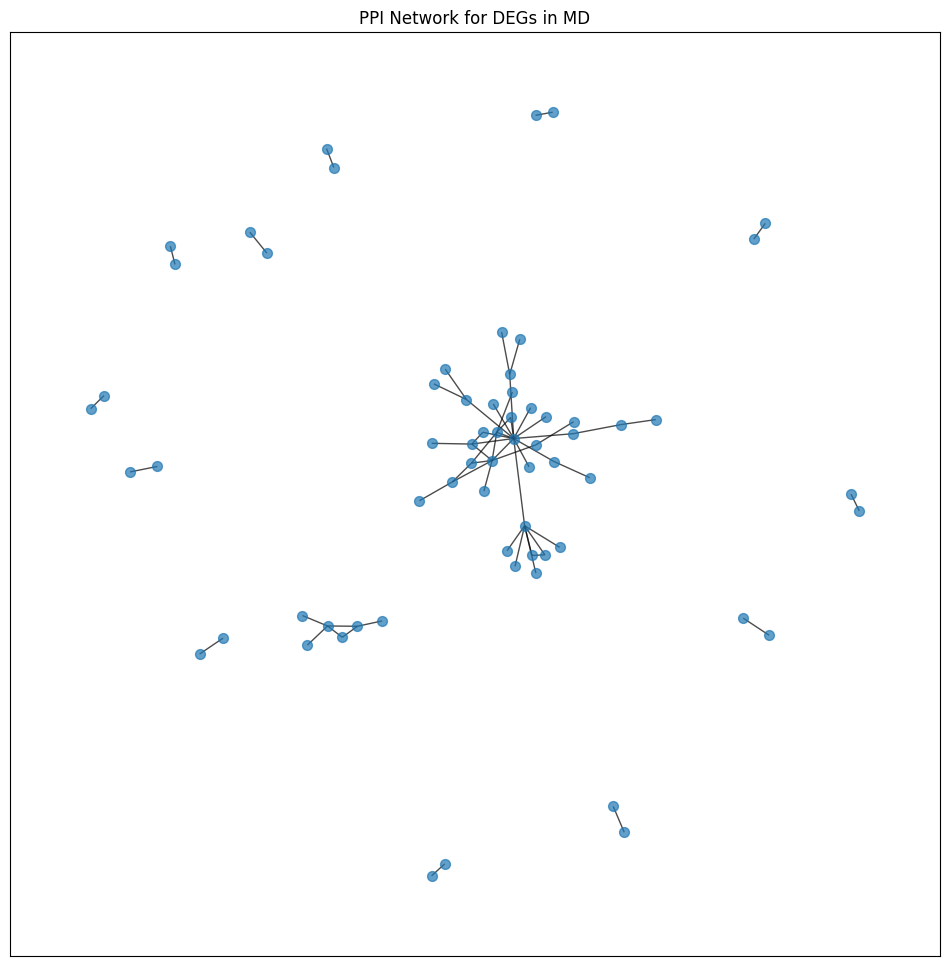

In [11]:
G = nx.Graph()
for _, row in ppi_df_filtered.iterrows():
    G.add_edge(row['preferredName_A'], row['preferredName_B'], weight=row['score'])
    
plt.figure(figsize=(12, 12))
nx.draw_networkx(G, node_size=50, with_labels=False, font_size=10, width=1, alpha=0.7)
plt.title('PPI Network for DEGs in MD')
plt.show()

In [12]:
print(f"Number of nodes: {G.number_of_nodes()}")
print(f"Number of edges: {G.number_of_edges()}")
print(f"Network density: {nx.density(G)}")

Number of nodes: 66
Number of edges: 60
Network density: 0.027972027972027972


Number of clusters: 14


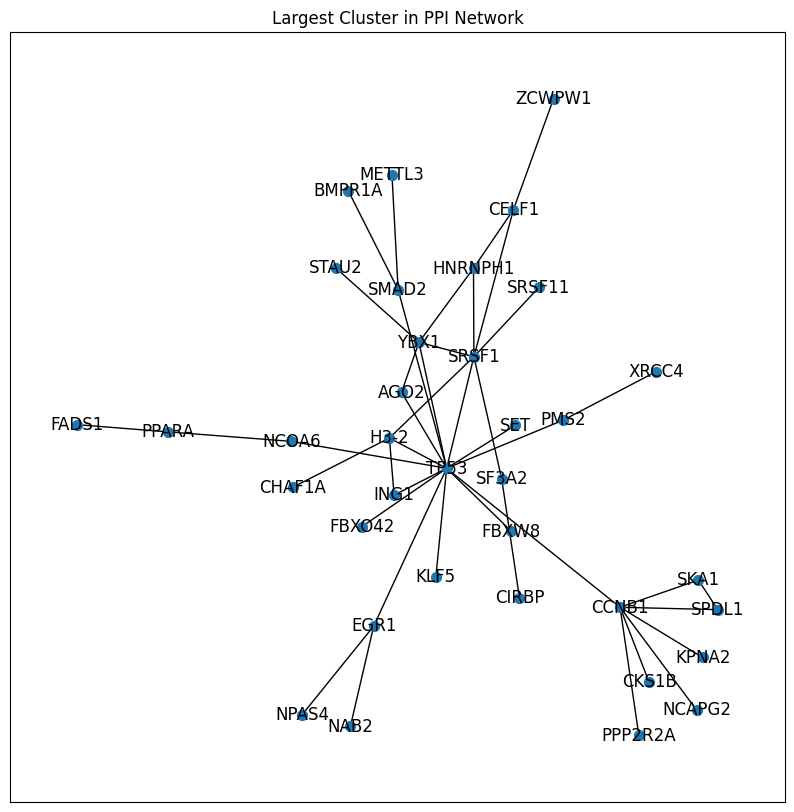

In [13]:
# Find connected components
components = list(nx.connected_components(G))
print(f"Number of clusters: {len(components)}")

# Get the largest cluster
largest_component = max(components, key=len)
subgraph = G.subgraph(largest_component)

# Visualize the largest cluster
plt.figure(figsize=(10, 10))
nx.draw_networkx(subgraph, node_size=50, with_labels=True)
plt.title("Largest Cluster in PPI Network")
plt.show()

In [14]:
components[2]

{'AGO2',
 'BMPR1A',
 'CCNB1',
 'CELF1',
 'CHAF1A',
 'CIRBP',
 'CKS1B',
 'EGR1',
 'FADS1',
 'FBXO42',
 'FBXW8',
 'H3-2',
 'HNRNPH1',
 'ING1',
 'KLF5',
 'KPNA2',
 'METTL3',
 'NAB2',
 'NCAPG2',
 'NCOA6',
 'NPAS4',
 'PMS2',
 'PPARA',
 'PPP2R2A',
 'SET',
 'SF3A2',
 'SKA1',
 'SMAD2',
 'SPDL1',
 'SRSF1',
 'SRSF11',
 'STAU2',
 'TP53',
 'XRCC4',
 'YBX1',
 'ZCWPW1'}

## Biological analysis

#### Genes Linked to the Peroxisome Pathway

**PPARA** (Peroxisome Proliferator Activated Receptor Alpha):

    Role: Master regulator of peroxisomal fatty acid β-oxidation and peroxisome proliferation.

    Mechanism: Activates genes encoding peroxisomal enzymes (e.g., ACOX1) and regulates lipid metabolism.

#### Genes Linked to Multiple Sclerosis (MS)
**EGR1** (Early Growth Response 1):

    Role: Transcription factor involved in T-cell activation, cytokine production, and neurodegeneration.

    MS Link: Dysregulated in MS patients, contributing to autoimmune inflammation.

**FADS1** (Fatty Acid Desaturase 1):

    Role: Modulates fatty acid metabolism (e.g., omega-3/6 pathways) and inflammation.

    MS Link: Polymorphisms in FADS1 alter lipid profiles and inflammatory responses, influencing MS risk.

**TP53** (Tumor Protein p53):

    Role: Tumor suppressor regulating DNA repair, apoptosis, and oxidative stress.

    MS Link: Dysfunctional TP53 may exacerbate neurodegeneration and immune dysregulation in MS.

#### Potential Interactions Ways Between Peroxisome and MS Pathways
**PPARA as a Bridge**:

    PPARA regulates peroxisomal lipid oxidation and also suppresses pro-inflammatory cytokines (e.g., TNF-α, IL-6) in immune cells.

    In MS, PPARA’s anti-inflammatory effects may counteract neuroinflammation while maintaining peroxisomal lipid homeostasis.

**Lipid Metabolism and Inflammation**:

    FADS1 and PPARA influence lipid mediators (e.g., resolvins, prostaglandins) that modulate both peroxisomal metabolism and immune responses.

    Dysregulated lipid metabolism (e.g., via FADS1 variants) could impair peroxisome function and exacerbate MS-related inflammation.

 **Oxidative Stress**:

    TP53 and PPARA interact in managing oxidative stress. PPARA enhances peroxisomal antioxidant defenses (e.g., catalase), while TP53 regulates DNA repair.

    In MS, oxidative damage to neurons and oligodendrocytes may involve failures in these pathways.

#### Key Takeaway
    PPARA is the central gene linking peroxisome function and MS via lipid metabolism and inflammation.

    FADS1, EGR1, and TP53 contribute to MS pathogenesis through immune dysregulation and oxidative stress, which may indirectly strain peroxisomal homeostasis.

    Therapeutic strategies targeting PPARA (e.g., fibrates) or lipid mediators (via FADS1) could address both peroxisome dysfunction and neuroinflammation in MS.

## Additional analysis (not included)
1. Rank the candidates based on degrees
2. Add the location of the genes in cell
3. co-regulation: check the promoter region of these genes
4. Relax the cutoff to get more clues